# 🏠 House Recognition - Image Classification
**Task:** Binary classification — detect whether a house is visible in a street-view image  
**Model:** EfficientNet-B3 (pretrained on ImageNet) fine-tuned with custom head  
**Metric:** Accuracy Score

## 1. Install & Import Libraries

In [ ]:
# Install required packages
!pip install -q timm albumentations kaggle

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device    : {DEVICE}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
Using device    : cuda


## 2. Download & Extract Dataset from Kaggle

In [ ]:
# ── Kaggle credentials ──────────────────────────────────────────────────────
os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
os.environ['KAGGLE_KEY']      = KAGGLE_KEY

# ── Download competition data ─────────────────────────────────────────────
COMP = 'PATH DATASET NAME'  # e.g., 'titanic', 'house-prices-advanced-regression-techniques', etc.
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

!kaggle competitions download -c {COMP} -p {DATA_DIR}

# ── Extract all zips ───────────────────────────────────────────────────────
import zipfile, glob

for zf in glob.glob(str(DATA_DIR / '*.zip')):
    print(f'Extracting {zf} ...')
    with zipfile.ZipFile(zf, 'r') as z:
        z.extractall(DATA_DIR)

print('\nFiles after extraction:')
for p in sorted(DATA_DIR.glob('*')):
    print(' ', p)

100% 1.25G/1.25G [00:05<00:00, 251MB/s]

Extracting data/super-ai-engineer-season-6-individual-hackathon-house-recognition.zip ...

Files after extraction:
  data/sample_submission.csv
  data/super-ai-engineer-season-6-individual-hackathon-house-recognition.zip
  data/test
  data/train
  data/train.csv


## 3. Exploratory Data Analysis (EDA)

In [ ]:
# ── Load annotations ───────────────────────────────────────────────────────
TRAIN_CSV  = DATA_DIR / 'train.csv'
SAMPLE_CSV = DATA_DIR / 'sample_submission.csv'
TRAIN_DIR  = DATA_DIR / 'train'
TEST_DIR   = DATA_DIR / 'test'

# Handle nested extraction directories if they exist
if (TRAIN_DIR / 'train').exists():
    TRAIN_DIR = TRAIN_DIR / 'train'
if (TEST_DIR / 'test').exists():
    TEST_DIR = TEST_DIR / 'test'

df_train  = pd.read_csv(TRAIN_CSV)
df_sample = pd.read_csv(SAMPLE_CSV)

# Standardize column names for consistency across the notebook
df_train = df_train.rename(columns={'image_name': 'id', 'class': 'answer'})

print('Train shape :', df_train.shape)
print('Test  shape :', df_sample.shape)
print('\nTrain head:')
display(df_train.head())
print('\nSample submission head:')
display(df_sample.head())

Train shape : (2953, 2)
Test  shape : (1550, 2)

Train head:


,id,answer
0,ChokChai4_img_13-7956791_100-6031267_a187-2159...,0
1,ChokChai4_img_13-7961753_100-6031881_a185-9785...,0
2,ChokChai4_img_13-7969811_100-5906061_a180-5812...,0
3,ChokChai4_img_13-7970811_100-5906071_a180-5812...,0
4,ChokChai4_img_13-7971811_100-5906081_a180-5812...,0



Sample submission head:


,id,answer
0,e4b420b0,0.0
1,23efa479,0.0
2,1f0f2402,0.0
3,8a60480c,NaN
4,11f20127,NaN


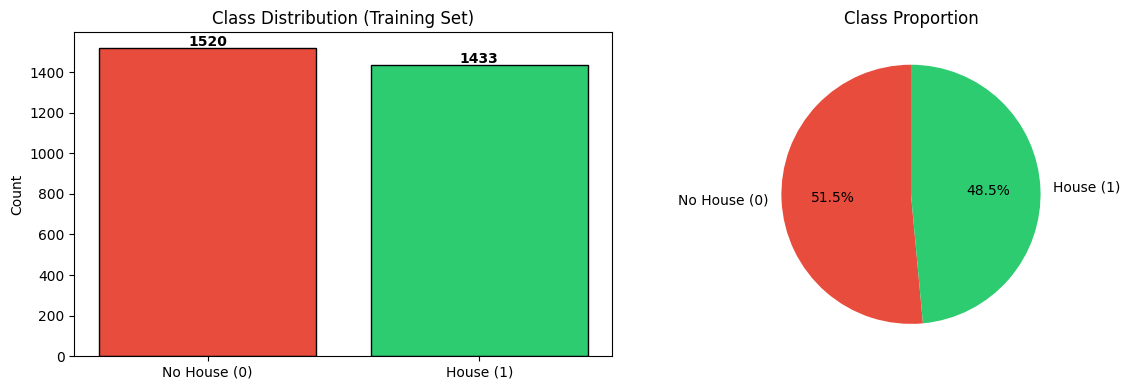

Class balance ratio (House / No-House): 0.943


In [ ]:
# ── Class distribution ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df_train['answer'].value_counts().sort_index()
axes[0].bar(['No House (0)', 'House (1)'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Class Distribution (Training Set)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No House (0)', 'House (1)'],
            autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'],
            startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()
print(f'Class balance ratio (House / No-House): {counts[1]/counts[0]:.3f}')

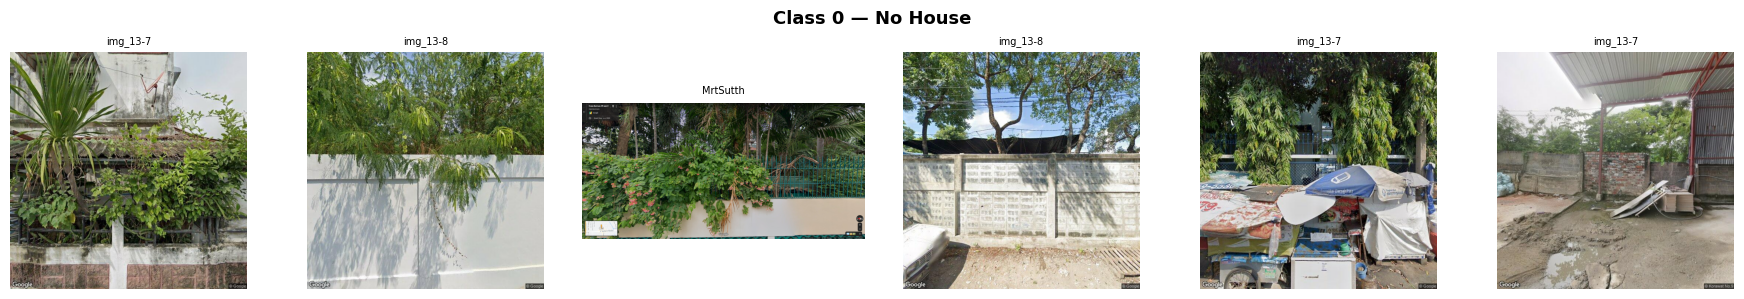

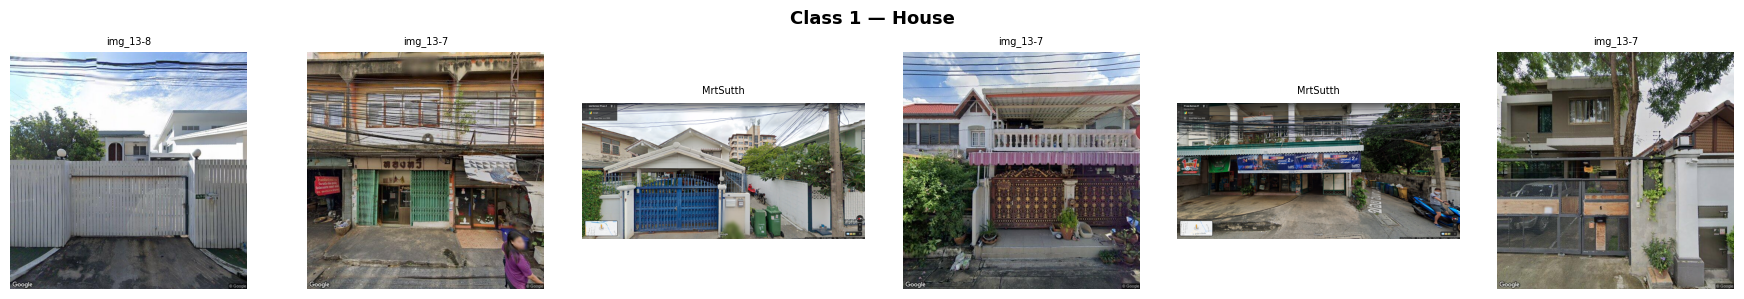

In [ ]:
# ── Sample images ──────────────────────────────────────────────────────────
def show_samples(df, label, n=6, title=''):
    subset = df[df['answer'] == label]
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    found = 0
    for _, row in subset.sample(frac=1, random_state=42).iterrows():
        img_name = row['id']
        img_path = TRAIN_DIR / img_name

        # If not found, try stripping the extension and looking for others
        if not img_path.exists():
            base_name = img_path.stem
            for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
                alt_path = TRAIN_DIR / f'{base_name}{ext}'
                if alt_path.exists():
                    img_path = alt_path
                    break

        if not img_path.exists():
            continue

        img = Image.open(img_path).convert('RGB')
        axes[found].imshow(img)
        axes[found].axis('off')
        axes[found].set_title(img_name[:8], fontsize=7)

        found += 1
        if found == n:
            break

    plt.tight_layout()
    plt.show()

show_samples(df_train, 0, title='Class 0 — No House')
show_samples(df_train, 1, title='Class 1 — House')

In [ ]:
import os
from pathlib import Path

print("Searching for the first 3 images from train.csv...")
for i, row in df_train.head(3).iterrows():
    img_name = row['id']
    base_name = Path(img_name).stem

    # Search recursively in DATA_DIR
    found = list(DATA_DIR.rglob(f"*{base_name}*"))
    print(f"\nTarget: {img_name}")
    if found:
        print(f"Found at: {found[0]}")
    else:
        print("Not found anywhere in data directory!")

print("\n--- First 10 files in data/train ---")
train_files = list(TRAIN_DIR.rglob('*.*'))[:10]
for f in train_files:
    print(f.relative_to(DATA_DIR))

Searching for the first 3 images from train.csv...

Target: ChokChai4_img_13-7956791_100-6031267_a187-21598902886774_s90_y0_f90_1.jpg
Found at: data/train/train/ChokChai4_img_13-7956791_100-6031267_a187-21598902886774_s90_y0_f90_1.jpg

Target: ChokChai4_img_13-7961753_100-6031881_a185-978546002526_s90_y0_f90_1.jpg
Found at: data/train/train/ChokChai4_img_13-7961753_100-6031881_a185-978546002526_s90_y0_f90_1.jpg

Target: ChokChai4_img_13-7969811_100-5906061_a180-5812875399312_s270_y0_f90_1.jpg
Found at: data/train/train/ChokChai4_img_13-7969811_100-5906061_a180-5812875399312_s270_y0_f90_1.jpg

--- First 10 files in data/train ---
train/train/img_13-7732054_100-5825859_a13-23419628_s283-23419628_y0_f90_1.jpg
train/train/img_13-7815869_100-5941672_a82-42238462_s352-42238462_y0_f90_1.jpg
train/train/img_13-8314898_100-5744563_a77-69291525_s347-69291525_y0_f90_1.jpg
train/train/img_13-7709363_100-5609667_a185-8533358_s275-85333579999997_y0_f90_1.jpg
train/train/img_13-7990204_100-6016362_a1

In [ ]:
# ── Image size distribution ─────────────────────────────────────────────────
widths, heights = [], []

# Search through shuffled dataset until we find 200 valid images
for img_name in df_train['id'].sample(frac=1, random_state=0):
    p = TRAIN_DIR / img_name

    if not p.exists():
        base_name = p.stem
        for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
            alt_path = TRAIN_DIR / f'{base_name}{ext}'
            if alt_path.exists():
                p = alt_path
                break

    if p.exists():
        w, h = Image.open(p).size
        widths.append(w); heights.append(h)
        if len(widths) >= 200:
            break

if len(widths) > 0:
    print(f'Successfully processed {len(widths)} images.')
    print(f'Width  — mean: {np.mean(widths):.0f} | min: {min(widths)} | max: {max(widths)}')
    print(f'Height — mean: {np.mean(heights):.0f} | min: {min(heights)} | max: {max(heights)}')
else:
    print('Warning: No valid images found to calculate dimensions.')

Successfully processed 200 images.
Width  — mean: 781 | min: 640 | max: 1920
Height — mean: 671 | min: 640 | max: 925


## 4. Configuration & Hyperparameters

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  ★  TUNE THESE PARAMETERS  ★
# ════════════════════════════════════════════════════════════════════════════
CFG = dict(
    # ── Model ──────────────────────────────────────────────────────────────
    model_name     = 'efficientnet_b3',   # Options: efficientnet_b0 ~ b7, resnet50, convnext_small
    pretrained     = True,
    num_classes    = 1,                   # Binary classification (BCEWithLogitsLoss)
    drop_rate      = 0.3,                 # Dropout rate in classifier head  [0.0 – 0.5]

    # ── Input ──────────────────────────────────────────────────────────────
    img_size       = 300,                 # EfficientNet-B3 native size = 300

    # ── Training ───────────────────────────────────────────────────────────
    epochs         = 20,
    batch_size     = 32,
    num_workers    = 4,

    # ── Optimizer ──────────────────────────────────────────────────────────
    optimizer      = 'adamw',             # 'adam' | 'adamw' | 'sgd'
    lr             = 3e-4,                # Initial learning rate
    weight_decay   = 1e-4,

    # ── Scheduler ──────────────────────────────────────────────────────────
    scheduler      = 'cosine',            # 'cosine' | 'step' | 'plateau'
    warmup_epochs  = 2,                   # Linear warmup steps
    min_lr         = 1e-6,

    # ── Fine-tuning strategy ───────────────────────────────────────────────
    freeze_epochs  = 3,                   # Epochs to train HEAD only before unfreezing backbone
    backbone_lr_ratio = 0.1,              # backbone_lr = lr * ratio  (discriminative LR)

    # ── Augmentation ───────────────────────────────────────────────────────
    use_mixup      = True,                # Mixup augmentation
    mixup_alpha    = 0.4,

    # ── Cross-validation ───────────────────────────────────────────────────
    n_folds        = 5,
    train_all      = True,                # After CV, retrain on full data

    # ── Misc ───────────────────────────────────────────────────────────────
    seed           = 42,
    label_smoothing = 0.1,
)

# ── Reproducibility ────────────────────────────────────────────────────────
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything(CFG['seed'])
print('Configuration loaded ✅')
for k, v in CFG.items():
    print(f'  {k:25s}: {v}')

Configuration loaded ✅
  model_name               : efficientnet_b3
  pretrained               : True
  num_classes              : 1
  drop_rate                : 0.3
  img_size                 : 300
  epochs                   : 20
  batch_size               : 32
  num_workers              : 4
  optimizer                : adamw
  lr                       : 0.0003
  weight_decay             : 0.0001
  scheduler                : cosine
  warmup_epochs            : 2
  min_lr                   : 1e-06
  freeze_epochs            : 3
  backbone_lr_ratio        : 0.1
  use_mixup                : True
  mixup_alpha              : 0.4
  n_folds                  : 5
  train_all                : True
  seed                     : 42
  label_smoothing          : 0.1


## 5. Dataset & Augmentation

In [ ]:
# ── Augmentation pipelines ────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.SmallestMaxSize(max_size=CFG['img_size'] + 32),
    A.RandomCrop(CFG['img_size'], CFG['img_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.1),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.5),
    A.OneOf([
        A.RandomBrightnessContrast(p=1.0),
        A.HueSaturationValue(p=1.0),
        A.CLAHE(p=1.0),
    ], p=0.5),
    A.GaussNoise(var_limit=(10, 50), p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32,
                    fill_value=0, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.SmallestMaxSize(max_size=CFG['img_size']),
    A.CenterCrop(CFG['img_size'], CFG['img_size']),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# TTA transform (test-time augmentation, used at inference)
tta_transforms = [
    val_transform,
    A.Compose([
        A.SmallestMaxSize(max_size=CFG['img_size']),
        A.CenterCrop(CFG['img_size'], CFG['img_size']),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ]),
]

print('Transforms defined ✅')

Transforms defined ✅


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_3408/970016562.py:17: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.3),
/tmp/ipykernel_3408/970016562.py:19: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32,


In [ ]:
def find_image(folder, img_id):
    """Return image path regardless of extension."""
    for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
        p = Path(folder) / f'{img_id}{ext}'
        if p.exists():
            return str(p)
    raise FileNotFoundError(f'{img_id} not found in {folder}')


class HouseDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.is_test   = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = find_image(self.img_dir, row['id'])
        img = np.array(Image.open(img_path).convert('RGB'))

        if self.transform:
            img = self.transform(image=img)['image']

        if self.is_test:
            return img, row['id']
        return img, torch.tensor(row['answer'], dtype=torch.float32)


print('Dataset class defined ✅')

Dataset class defined ✅


## 6. Model Definition

In [ ]:
class HouseClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b3', pretrained=True,
                 num_classes=1, drop_rate=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=0,          # remove classifier head
            drop_rate=drop_rate,
        )
        in_features = self.backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(drop_rate),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.Dropout(drop_rate / 2),
            nn.Linear(256, num_classes),
        )

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features).squeeze(1)   # (B,)


# Quick sanity check
model_test = HouseClassifier(
    CFG['model_name'], pretrained=False,
    num_classes=CFG['num_classes'], drop_rate=CFG['drop_rate']
)
dummy = torch.randn(2, 3, CFG['img_size'], CFG['img_size'])
out   = model_test(dummy)
print(f'Output shape: {out.shape}  ✅   (expected: torch.Size([2]))')
total_params = sum(p.numel() for p in model_test.parameters()) / 1e6
print(f'Total parameters: {total_params:.2f}M')
del model_test, dummy, out

Output shape: torch.Size([2])  ✅   (expected: torch.Size([2]))
Total parameters: 11.09M


## 7. Training Utilities

In [ ]:
# ── Loss ──────────────────────────────────────────────────────────────────
class BCELossWithSmoothing(nn.Module):
    """Binary cross-entropy with label smoothing."""
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, logits, targets):
        # Smooth targets: 1 -> (1 - ε), 0 -> ε
        smooth_targets = targets * (1 - self.smoothing) + 0.5 * self.smoothing
        return nn.functional.binary_cross_entropy_with_logits(
            logits, smooth_targets
        )


# ── Mixup ─────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=0.4):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    y_a, y_b = y, y[idx]
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


# ── Optimizer factory ─────────────────────────────────────────────────────
def build_optimizer(model, cfg, stage='head_only'):
    """Return optimizer. stage = 'head_only' | 'full'"""
    if stage == 'head_only':
        params = model.head.parameters()
        lr = cfg['lr']
    else:
        params = [
            {'params': model.backbone.parameters(),
             'lr': cfg['lr'] * cfg['backbone_lr_ratio']},
            {'params': model.head.parameters(),
             'lr': cfg['lr']},
        ]
        lr = cfg['lr']

    opt_name = cfg['optimizer'].lower()
    if opt_name == 'adamw':
        if stage == 'head_only':
            return optim.AdamW(params, lr=lr, weight_decay=cfg['weight_decay'])
        return optim.AdamW(params, weight_decay=cfg['weight_decay'])
    elif opt_name == 'adam':
        if stage == 'head_only':
            return optim.Adam(params, lr=lr)
        return optim.Adam(params)
    elif opt_name == 'sgd':
        if stage == 'head_only':
            return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=cfg['weight_decay'])
        return optim.SGD(params, momentum=0.9, weight_decay=cfg['weight_decay'])
    raise ValueError(f"Unknown optimizer: {opt_name}")


# ── Scheduler factory ─────────────────────────────────────────────────────
def build_scheduler(optimizer, cfg, steps_per_epoch):
    total_steps   = cfg['epochs'] * steps_per_epoch
    warmup_steps  = cfg['warmup_epochs'] * steps_per_epoch

    def warmup_lr(step):
        if step < warmup_steps:
            return float(step) / max(1, warmup_steps)
        return 1.0

    sched_name = cfg['scheduler'].lower()
    if sched_name == 'cosine':
        cosine = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=total_steps - warmup_steps,
            eta_min=cfg['min_lr'],
        )
        warmup = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_lr)
        return optim.lr_scheduler.SequentialLR(
            optimizer, schedulers=[warmup, cosine],
            milestones=[warmup_steps]
        )
    elif sched_name == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    elif sched_name == 'plateau':
        return optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', patience=3, factor=0.5)
    raise ValueError(f"Unknown scheduler: {sched_name}")


print('Training utilities defined ✅')

Training utilities defined ✅


In [ ]:
# ── One epoch train / eval ─────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, scheduler, criterion, cfg, epoch):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    for step, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        if cfg['use_mixup']:
            images, y_a, y_b, lam = mixup_data(images, labels, cfg['mixup_alpha'])
            logits = model(images)
            loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        else:
            logits = model(images)
            loss   = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if cfg['scheduler'] != 'plateau':
            scheduler.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_probs, all_labels = 0.0, [], [], []

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        loss   = criterion(logits, labels)

        total_loss += loss.item()
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, f1, auc, np.array(all_probs), np.array(all_labels)


print('Epoch functions defined ✅')

Epoch functions defined ✅


## 8. Cross-Validation Training

In [ ]:
def find_image(folder, img_id):
    """Return image path regardless of extension."""
    base_name = Path(img_id).stem
    for ext in ['.jpg', '.jpeg', '.png', '.JPG']:
        p = Path(folder) / f'{base_name}{ext}'
        if p.exists():
            return str(p)
    # Fallback: try exact match if provided
    p_exact = Path(folder) / img_id
    if p_exact.exists():
        return str(p_exact)
    raise FileNotFoundError(f'{img_id} not found in {folder}')

def run_fold(df_tr, df_val, fold_idx, cfg):
    """Train one fold and return best val accuracy + oof probs."""
    print(f'\n{"="*60}')
    print(f'  FOLD {fold_idx+1}/{cfg["n_folds"]}')
    print(f'{"="*60}')

    # Datasets & loaders
    train_ds = HouseDataset(df_tr, TRAIN_DIR, transform=train_transform)
    val_ds   = HouseDataset(df_val, TRAIN_DIR, transform=val_transform)

    train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'],
                              shuffle=True,  num_workers=cfg['num_workers'],
                              pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=cfg['batch_size'] * 2,
                              shuffle=False, num_workers=cfg['num_workers'],
                              pin_memory=True)

    # Model
    model = HouseClassifier(
        cfg['model_name'], cfg['pretrained'],
        cfg['num_classes'], cfg['drop_rate']
    ).to(DEVICE)

    criterion = BCELossWithSmoothing(cfg['label_smoothing'])
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [],
                 'val_acc': [], 'val_f1': [], 'val_auc': []}

    # ── Phase 1: train head only ──────────────────────────────────────────
    model.freeze_backbone()
    optimizer = build_optimizer(model, cfg, stage='head_only')
    scheduler = build_scheduler(optimizer, cfg, len(train_loader))
    best_acc, best_weights = 0.0, None

    for epoch in range(cfg['epochs']):
        # Unfreeze backbone after freeze_epochs
        if epoch == cfg['freeze_epochs']:
            print(f'  [Epoch {epoch+1}] Unfreezing backbone ...')
            model.unfreeze_backbone()
            optimizer = build_optimizer(model, cfg, stage='full')
            scheduler = build_scheduler(optimizer, cfg, len(train_loader))

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, optimizer, scheduler, criterion, cfg, epoch)
        v_loss, v_acc, v_f1, v_auc, _, _ = validate(model, val_loader, criterion)

        # Update scheduler if plateau
        if cfg['scheduler'] == 'plateau':
            scheduler.step(v_acc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(v_acc)
        history['val_f1'].append(v_f1)
        history['val_auc'].append(v_auc)

        print(f'  Ep {epoch+1:03d} | '
              f'tr_loss={tr_loss:.4f} acc={tr_acc:.4f} | '
              f'val_loss={v_loss:.4f} acc={v_acc:.4f} '
              f'f1={v_f1:.4f} auc={v_auc:.4f}')

        if v_acc > best_acc:
            best_acc     = v_acc
            best_weights = {k: v.cpu().clone()
                            for k, v in model.state_dict().items()}
            torch.save(best_weights, f'best_model_fold{fold_idx}.pth')
            print(f'  ✔ Saved best model (acc={best_acc:.4f})')

    # ── Load best weights & get OOF predictions ───────────────────────────
    model.load_state_dict(best_weights)
    _, _, _, _, oof_probs, oof_labels = validate(model, val_loader, criterion)

    return history, oof_probs, oof_labels, best_acc


# ── Run K-Fold CV ──────────────────────────────────────────────────────────
skf = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True,
                      random_state=CFG['seed'])

oof_probs_all  = np.zeros(len(df_train))
oof_labels_all = np.zeros(len(df_train))
fold_histories = []
fold_best_accs = []

for fold, (tr_idx, val_idx) in enumerate(
        skf.split(df_train, df_train['answer'])):

    df_tr  = df_train.iloc[tr_idx]
    df_val = df_train.iloc[val_idx]

    hist, probs, labels, best_acc = run_fold(df_tr, df_val, fold, CFG)

    oof_probs_all[val_idx]  = probs
    oof_labels_all[val_idx] = labels
    fold_histories.append(hist)
    fold_best_accs.append(best_acc)

print('\n' + '='*60)
print('CROSS-VALIDATION SUMMARY')
for i, acc in enumerate(fold_best_accs):
    print(f'  Fold {i+1}: Best Val Acc = {acc:.4f}')
print(f'  Mean: {np.mean(fold_best_accs):.4f}  Std: {np.std(fold_best_accs):.4f}')
oof_acc = accuracy_score(oof_labels_all, (oof_probs_all > 0.5).astype(int))
oof_auc = roc_auc_score(oof_labels_all, oof_probs_all)
print(f'  OOF  Accuracy: {oof_acc:.4f}')
print(f'  OOF  AUC-ROC : {oof_auc:.4f}')


  FOLD 1/5
  Ep 001 | tr_loss=0.6471 acc=0.5745 | val_loss=0.4805 acc=0.8342 f1=0.8328 auc=0.9108
  ✔ Saved best model (acc=0.8342)
  Ep 002 | tr_loss=0.5416 acc=0.6824 | val_loss=0.4119 acc=0.8697 f1=0.8597 auc=0.9459
  ✔ Saved best model (acc=0.8697)
  Ep 003 | tr_loss=0.5362 acc=0.6340 | val_loss=0.4079 acc=0.8629 f1=0.8525 auc=0.9422
  [Epoch 4] Unfreezing backbone ...
  Ep 004 | tr_loss=0.5387 acc=0.6597 | val_loss=0.3867 acc=0.8849 f1=0.8773 auc=0.9553
  ✔ Saved best model (acc=0.8849)
  Ep 005 | tr_loss=0.5433 acc=0.6306 | val_loss=0.3630 acc=0.9069 f1=0.9009 auc=0.9677
  ✔ Saved best model (acc=0.9069)
  Ep 006 | tr_loss=0.5033 acc=0.6618 | val_loss=0.3465 acc=0.9086 f1=0.9075 auc=0.9741
  ✔ Saved best model (acc=0.9086)
  Ep 007 | tr_loss=0.4965 acc=0.7136 | val_loss=0.3438 acc=0.9171 f1=0.9148 auc=0.9754
  ✔ Saved best model (acc=0.9171)
  Ep 008 | tr_loss=0.4959 acc=0.6986 | val_loss=0.3451 acc=0.9239 f1=0.9212 auc=0.9760
  ✔ Saved best model (acc=0.9239)
  Ep 009 | tr_loss

## 9. Training Metrics Visualization

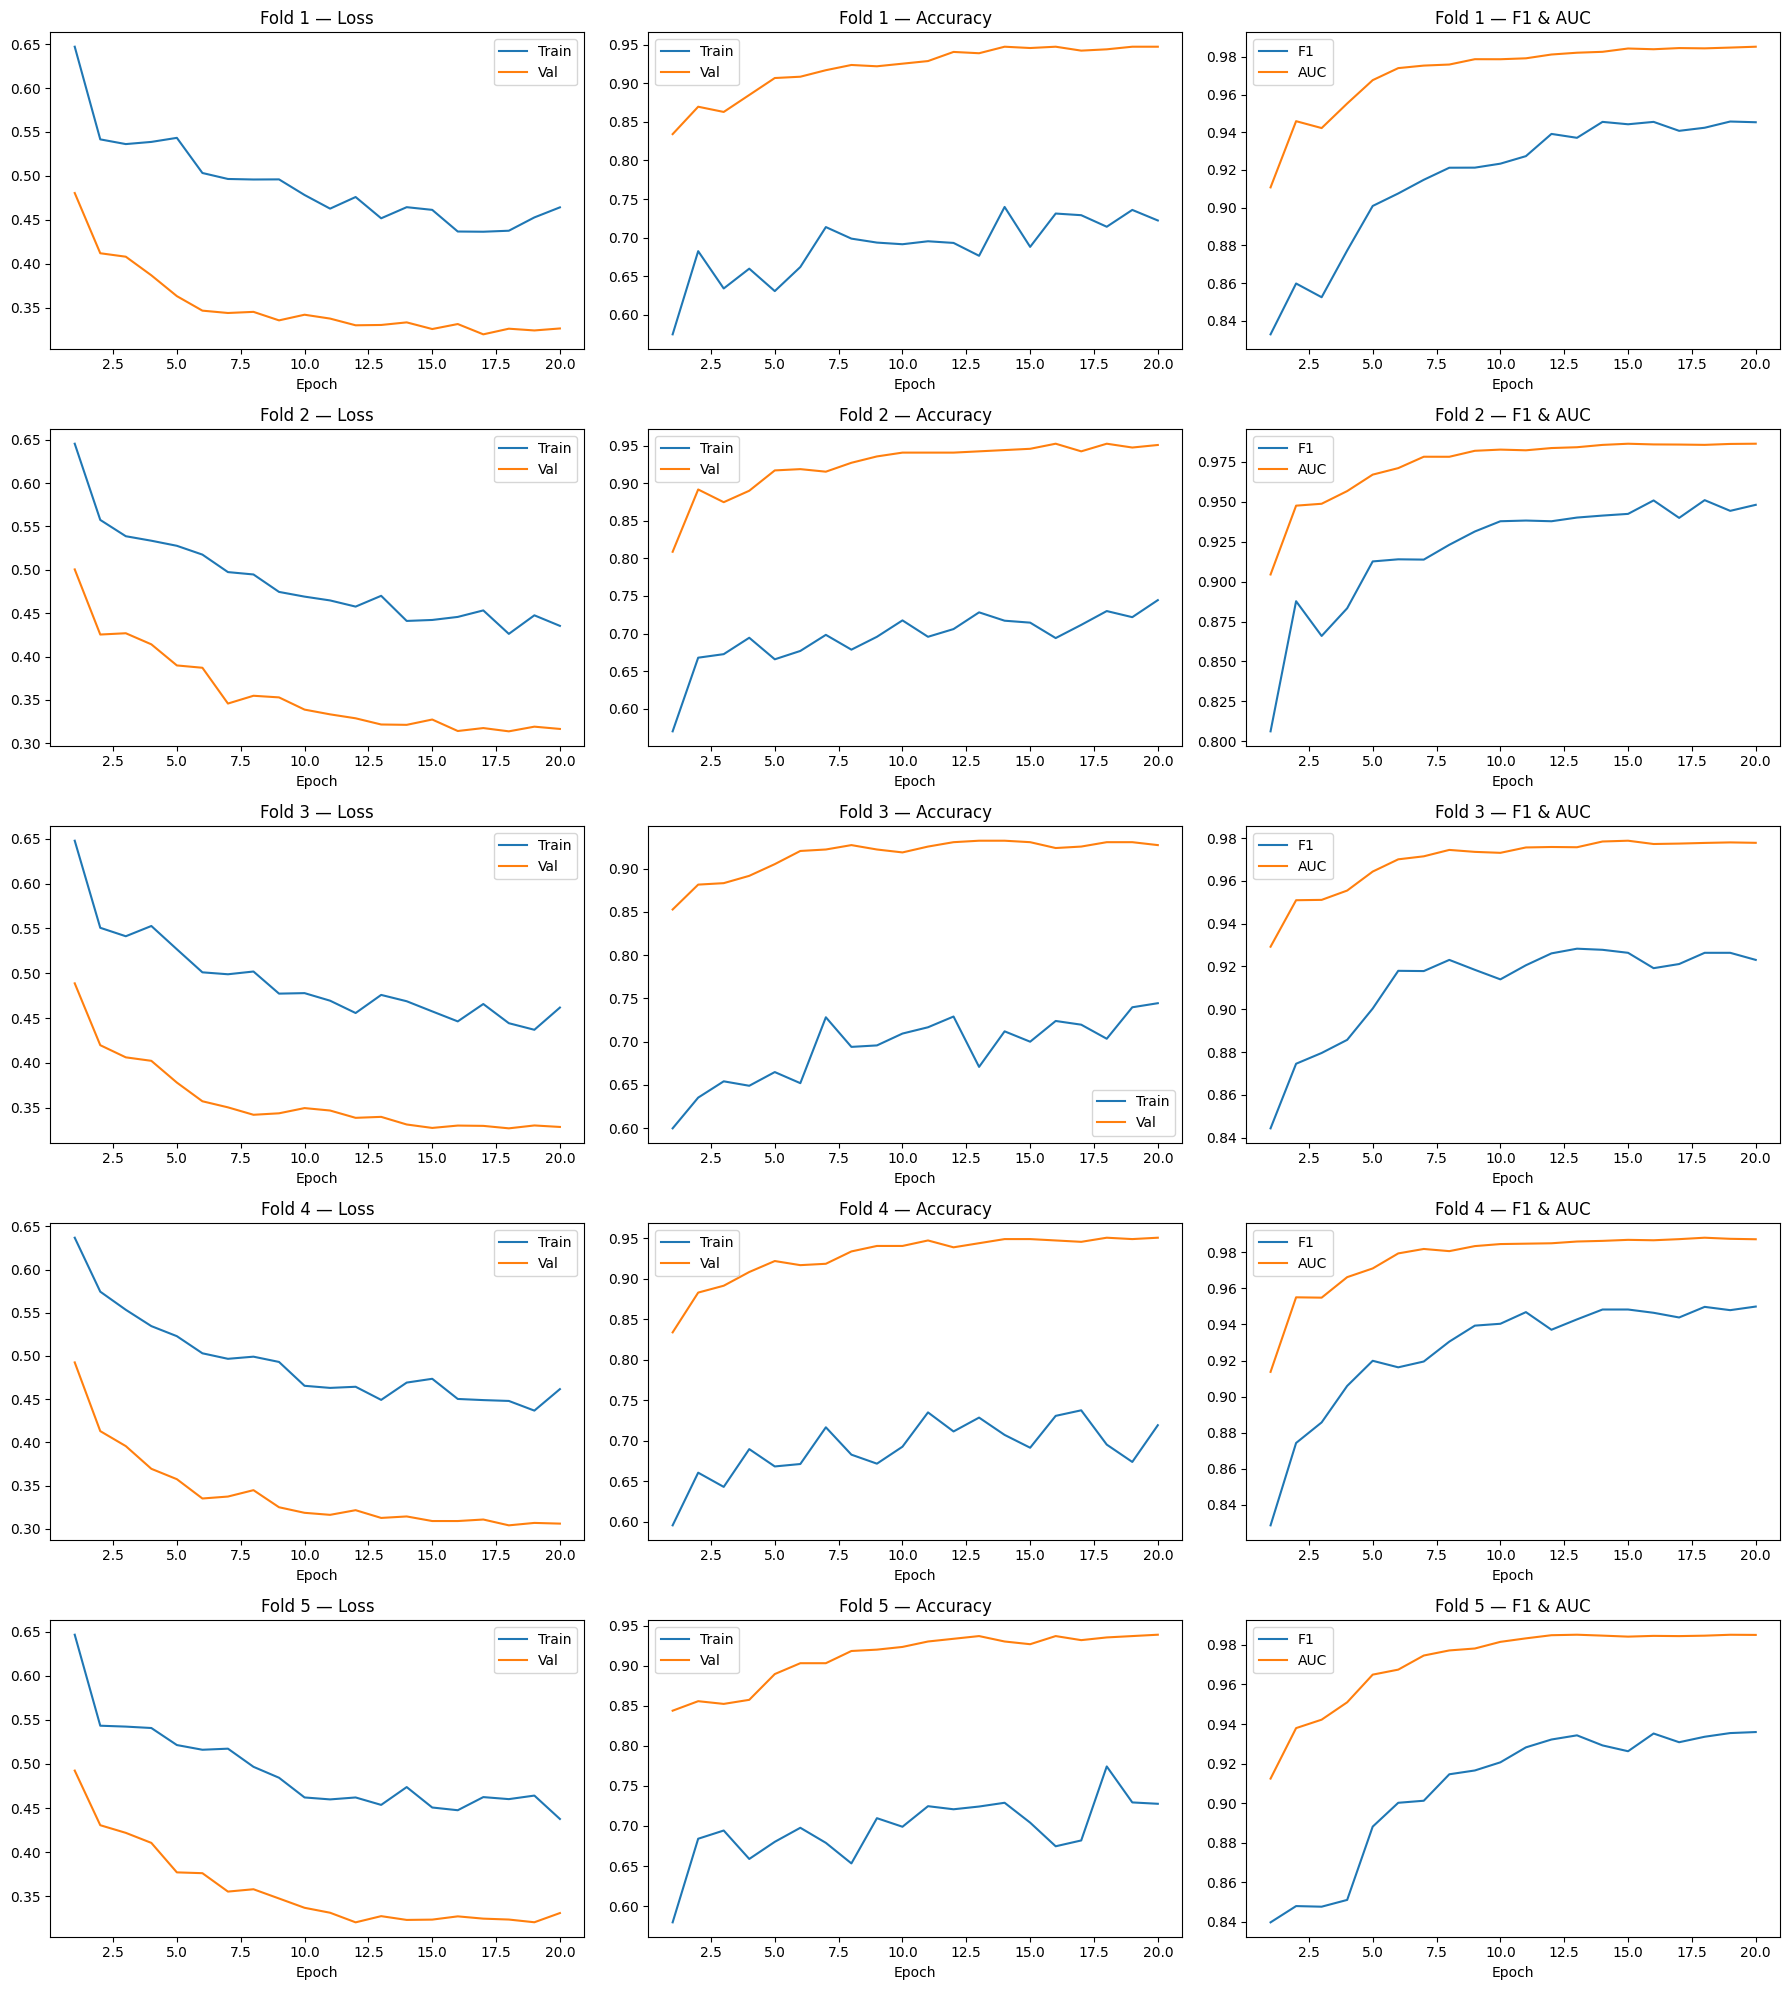

Saved training_curves.png


In [ ]:
fig, axes = plt.subplots(CFG['n_folds'], 3,
                         figsize=(18, 4 * CFG['n_folds']))

for fold, hist in enumerate(fold_histories):
    ep = range(1, len(hist['train_loss']) + 1)

    axes[fold, 0].plot(ep, hist['train_loss'], label='Train')
    axes[fold, 0].plot(ep, hist['val_loss'],   label='Val')
    axes[fold, 0].set_title(f'Fold {fold+1} — Loss')
    axes[fold, 0].legend(); axes[fold, 0].set_xlabel('Epoch')

    axes[fold, 1].plot(ep, hist['train_acc'], label='Train')
    axes[fold, 1].plot(ep, hist['val_acc'],   label='Val')
    axes[fold, 1].set_title(f'Fold {fold+1} — Accuracy')
    axes[fold, 1].legend(); axes[fold, 1].set_xlabel('Epoch')

    axes[fold, 2].plot(ep, hist['val_f1'],  label='F1')
    axes[fold, 2].plot(ep, hist['val_auc'], label='AUC')
    axes[fold, 2].set_title(f'Fold {fold+1} — F1 & AUC')
    axes[fold, 2].legend(); axes[fold, 2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()
print('Saved training_curves.png')

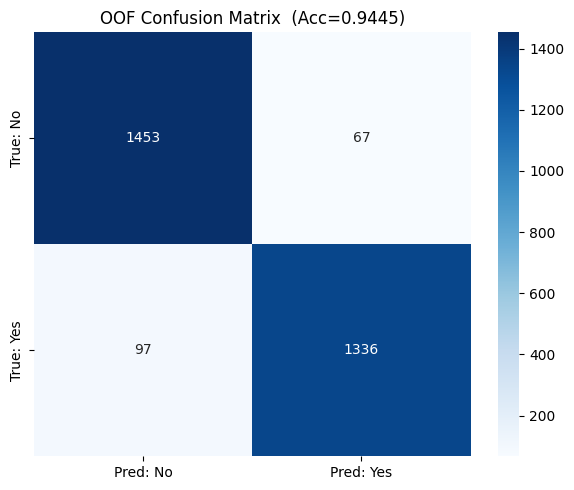

              precision    recall  f1-score   support

No House (0)       0.94      0.96      0.95      1520
   House (1)       0.95      0.93      0.94      1433

    accuracy                           0.94      2953
   macro avg       0.94      0.94      0.94      2953
weighted avg       0.94      0.94      0.94      2953



In [ ]:
# ── OOF Confusion Matrix ───────────────────────────────────────────────────
oof_pred_labels = (oof_probs_all > 0.5).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(oof_labels_all, oof_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No', 'Pred: Yes'],
            yticklabels=['True: No', 'True: Yes'], ax=ax)
ax.set_title(f'OOF Confusion Matrix  (Acc={oof_acc:.4f})')
plt.tight_layout()
plt.savefig('oof_confusion_matrix.png', dpi=100)
plt.show()

print(classification_report(
    oof_labels_all, oof_pred_labels,
    target_names=['No House (0)', 'House (1)']
))

## 10. (Optional) Retrain on Full Training Data

In [ ]:
if CFG['train_all']:
    print('Retraining on FULL training set ...')

    full_ds     = HouseDataset(df_train, TRAIN_DIR, transform=train_transform)
    full_loader = DataLoader(full_ds, batch_size=CFG['batch_size'],
                             shuffle=True, num_workers=CFG['num_workers'],
                             pin_memory=True, drop_last=True)

    model_full = HouseClassifier(
        CFG['model_name'], CFG['pretrained'],
        CFG['num_classes'], CFG['drop_rate']
    ).to(DEVICE)

    criterion  = BCELossWithSmoothing(CFG['label_smoothing'])
    model_full.freeze_backbone()
    optimizer  = build_optimizer(model_full, CFG, stage='head_only')
    scheduler  = build_scheduler(optimizer, CFG, len(full_loader))

    for epoch in range(CFG['epochs']):
        if epoch == CFG['freeze_epochs']:
            model_full.unfreeze_backbone()
            optimizer = build_optimizer(model_full, CFG, stage='full')
            scheduler = build_scheduler(optimizer, CFG, len(full_loader))

        tr_loss, tr_acc = train_one_epoch(
            model_full, full_loader, optimizer, scheduler,
            criterion, CFG, epoch)
        print(f'  Ep {epoch+1:03d} | loss={tr_loss:.4f} acc={tr_acc:.4f}')

    torch.save(model_full.state_dict(), 'model_full.pth')
    print('Saved model_full.pth ✅')

Retraining on FULL training set ...
  Ep 001 | loss=0.6390 acc=0.5893
  Ep 002 | loss=0.5528 acc=0.6518
  Ep 003 | loss=0.5515 acc=0.6596
  Ep 004 | loss=0.5462 acc=0.6512
  Ep 005 | loss=0.5215 acc=0.6447
  Ep 006 | loss=0.5047 acc=0.6739
  Ep 007 | loss=0.5161 acc=0.6552
  Ep 008 | loss=0.4636 acc=0.6647
  Ep 009 | loss=0.4687 acc=0.7130
  Ep 010 | loss=0.4724 acc=0.7041
  Ep 011 | loss=0.4686 acc=0.7347
  Ep 012 | loss=0.4597 acc=0.7255
  Ep 013 | loss=0.4476 acc=0.7249
  Ep 014 | loss=0.4545 acc=0.7537
  Ep 015 | loss=0.4360 acc=0.7493
  Ep 016 | loss=0.4507 acc=0.6946
  Ep 017 | loss=0.4371 acc=0.7531
  Ep 018 | loss=0.4327 acc=0.7418
  Ep 019 | loss=0.4456 acc=0.7188
  Ep 020 | loss=0.4209 acc=0.7632
Saved model_full.pth ✅


## 11. Inference on Test Set (with TTA)

In [ ]:
@torch.no_grad()
def predict_test(model, df_test, img_dir, tta_tfms, batch_size=32, num_workers=4):
    """Run TTA and return averaged probability for each test image."""
    model.eval()
    all_ids, all_probs_tta = [], []

    for tfm in tta_tfms:
        ds     = HouseDataset(df_test, img_dir, transform=tfm, is_test=True)
        loader = DataLoader(ds, batch_size=batch_size * 2,
                            shuffle=False, num_workers=num_workers,
                            pin_memory=True)
        probs_this_tta, ids_this = [], []

        for images, ids in loader:
            images = images.to(DEVICE)
            logits = model(images)
            probs  = torch.sigmoid(logits).cpu().numpy()
            probs_this_tta.extend(probs)
            ids_this.extend(ids)

        all_probs_tta.append(np.array(probs_this_tta))
        if not all_ids:
            all_ids = ids_this

    avg_probs = np.mean(all_probs_tta, axis=0)
    return all_ids, avg_probs


# Use model trained on full data (or last fold model)
if CFG['train_all']:
    inference_model = model_full
else:
    # Ensemble predictions from all fold models
    inference_model = HouseClassifier(
        CFG['model_name'], pretrained=False,
        num_classes=CFG['num_classes'], drop_rate=CFG['drop_rate']
    ).to(DEVICE)
    # Load best fold model
    inference_model.load_state_dict(
        torch.load(f'best_model_fold{np.argmax(fold_best_accs)}.pth',
                   map_location=DEVICE))

test_ids, test_probs = predict_test(
    inference_model, df_sample, TEST_DIR,
    tta_tfms=tta_transforms,
    batch_size=CFG['batch_size'],
    num_workers=CFG['num_workers'],
)

print(f'Test predictions done. Shape: {len(test_ids)} samples')
print(f'Prob range: [{test_probs.min():.4f}, {test_probs.max():.4f}]')

Test predictions done. Shape: 1550 samples
Prob range: [0.0062, 0.9894]


## 12. Ensemble from All Folds (optional but recommended)

Fold 1 predictions done.
Fold 2 predictions done.
Fold 3 predictions done.
Fold 4 predictions done.
Fold 5 predictions done.

Ensemble prob range: [0.0065, 0.9866]


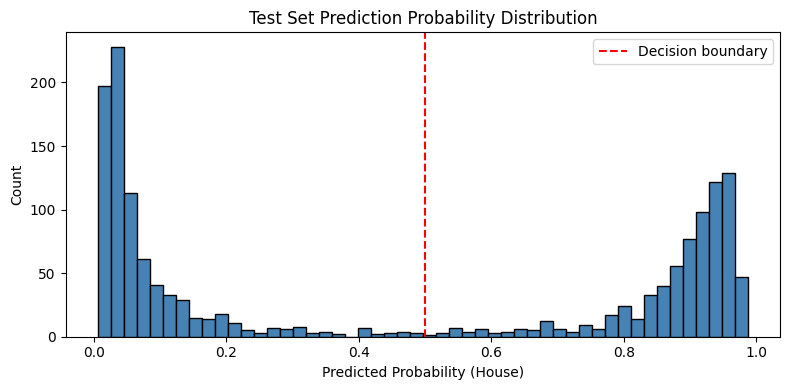

In [ ]:
# Ensemble predictions from all fold models (weighted by fold accuracy)
fold_test_probs = []

for fold_idx in range(CFG['n_folds']):
    fold_model = HouseClassifier(
        CFG['model_name'], pretrained=False,
        num_classes=CFG['num_classes'], drop_rate=CFG['drop_rate']
    ).to(DEVICE)
    fold_model.load_state_dict(
        torch.load(f'best_model_fold{fold_idx}.pth', map_location=DEVICE))

    _, fp = predict_test(
        fold_model, df_sample, TEST_DIR,
        tta_tfms=tta_transforms,
        batch_size=CFG['batch_size'],
        num_workers=CFG['num_workers'],
    )
    fold_test_probs.append(fp)
    print(f'Fold {fold_idx+1} predictions done.')

# Weighted average by validation accuracy
weights = np.array(fold_best_accs)
weights = weights / weights.sum()
ensemble_probs = np.average(fold_test_probs, axis=0, weights=weights)

print(f'\nEnsemble prob range: [{ensemble_probs.min():.4f}, {ensemble_probs.max():.4f}]')

# Plot probability distribution
plt.figure(figsize=(8, 4))
plt.hist(ensemble_probs, bins=50, edgecolor='black', color='steelblue')
plt.axvline(0.5, color='red', linestyle='--', label='Decision boundary')
plt.title('Test Set Prediction Probability Distribution')
plt.xlabel('Predicted Probability (House)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('test_prob_distribution.png', dpi=100)
plt.show()

## 13. Save Submission CSV

In [ ]:
# ── Use ensemble probs if available, else single-model probs ──────────────
final_probs   = ensemble_probs  # change to test_probs for single model
final_answers = (final_probs > 0.5).astype(int)

submission = pd.DataFrame({
    'id'    : df_sample['id'].values,
    'answer': final_answers,
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved ✅')

display(submission.head(10))
print(f'\nClass distribution in submission:')
print(submission['answer'].value_counts().rename({0:'No House(0)', 1:'House(1)'}))

# Sanity check: same format as sample_submission
print(f'\nRows match sample_submission: {len(submission) == len(df_sample)}')
print(f'IDs match: {(submission["id"].values == df_sample["id"].values).all()}')

submission.csv saved ✅


,id,answer
0,e4b420b0,0
1,23efa479,0
2,1f0f2402,0
3,8a60480c,0
4,11f20127,0
5,16173ced,0
6,9c05fea1,0
7,11f04229,0
8,c055fbb7,0
9,ec045077,0



Class distribution in submission:
answer
No House(0)    817
House(1)       733
Name: count, dtype: int64

Rows match sample_submission: True
IDs match: True


## 14. Visualize Predictions on Test Images

/tmp/ipykernel_3408/3370251116.py:18: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3408/3370251116.py:18: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3408/3370251116.py:19: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_predictions.png', dpi=100)
/tmp/ipykernel_3408/3370251116.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('sample_predictions.png', dpi=100)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_i

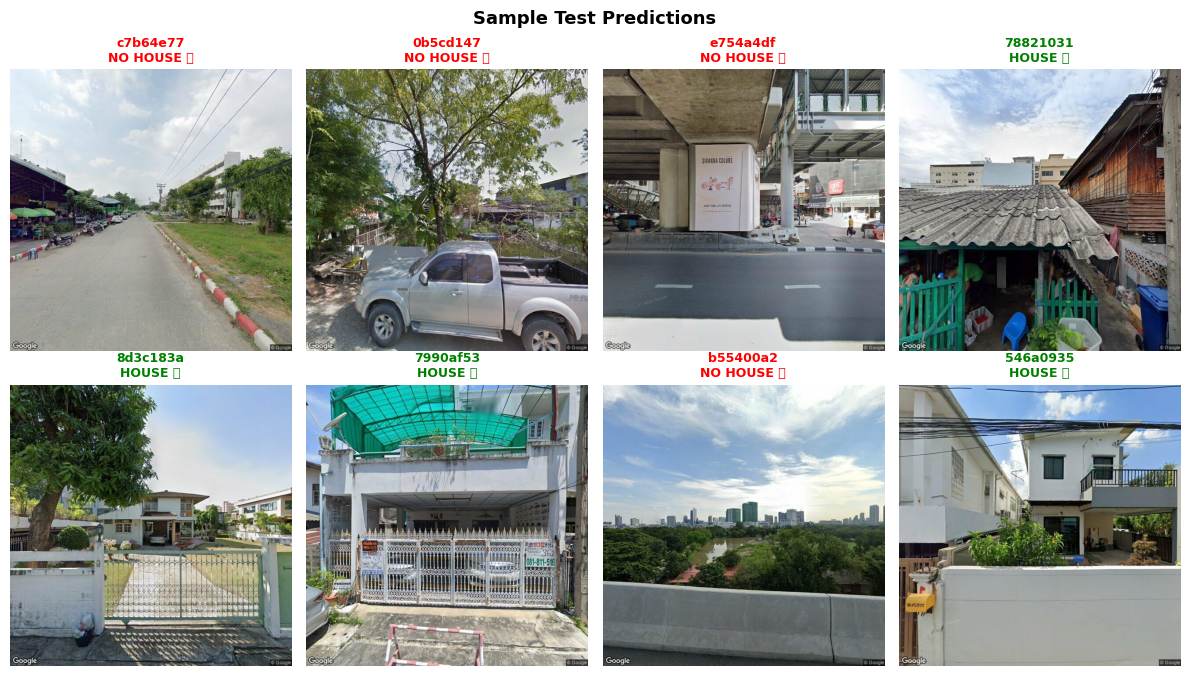

In [ ]:
n_show = 8
sample_sub = submission.sample(n_show, random_state=0)

fig, axes = plt.subplots(2, n_show // 2, figsize=(3 * (n_show // 2), 7))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_sub.iterrows()):
    img_path = find_image(TEST_DIR, row['id'])
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    label = 'HOUSE ✅' if row['answer'] == 1 else 'NO HOUSE ❌'
    color = 'green' if row['answer'] == 1 else 'red'
    ax.set_title(f"{row['id'][:8]}\n{label}",
                 color=color, fontsize=9, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Test Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=100)
plt.show()

In [ ]:
print('='*60)
print('FINAL SUMMARY')
print('='*60)
print(f'Model           : {CFG["model_name"]}')
print(f'Image size      : {CFG["img_size"]}')
print(f'Epochs          : {CFG["epochs"]}')
print(f'Batch size      : {CFG["batch_size"]}')
print(f'Optimizer       : {CFG["optimizer"]}  (lr={CFG["lr"]})')
print(f'Scheduler       : {CFG["scheduler"]}')
print(f'CV Folds        : {CFG["n_folds"]}')
print(f'Mean CV Acc     : {np.mean(fold_best_accs):.4f} ± {np.std(fold_best_accs):.4f}')
print(f'OOF Accuracy    : {oof_acc:.4f}')
print(f'OOF AUC-ROC     : {oof_auc:.4f}')
print(f'Submission rows : {len(submission)}')
print(f'Predicted House : {(submission["answer"]==1).sum()}')
print(f'Predicted No    : {(submission["answer"]==0).sum()}')
print('submission.csv  → ready to upload ✅')

FINAL SUMMARY
Model           : efficientnet_b3
Image size      : 300
Epochs          : 20
Batch size      : 32
Optimizer       : adamw  (lr=0.0003)
Scheduler       : cosine
CV Folds        : 5
Mean CV Acc     : 0.9445 ± 0.0077
OOF Accuracy    : 0.9445
OOF AUC-ROC     : 0.9832
Submission rows : 1550
Predicted House : 733
Predicted No    : 817
submission.csv  → ready to upload ✅
